# Survival Analysis Extension
## Predicting Time to 30-Day Readmission in Medicare Patients (MIMIC-IV v3.1)

**Why this extension?** The binary 30-day readmission target answers *whether* a patient is readmitted, not *when*, and labels in-hospital deaths within the 30-day window as "not readmitted" even though those patients could not possibly have been readmitted. A survival reframing fixes both issues:

1. **Time-to-event modeling** produces a risk curve over the post-discharge window, so a discharge team can plan when to schedule follow-up (day 7 vs day 14 vs day 21).
2. **Competing risks** (death without readmission) are handled properly via Fine-Gray subdistribution hazards.
3. **Interpretability** is preserved via SurvSHAP(t), the time-dependent extension of SHAP.

**What this notebook does.**
- Reconstructs the cohort from `admissions.parquet` to compute time-to-event and the competing-event indicator.
- Reuses the V7 50-feature matrix and the saved `v7_split_indices.npz` so every result is directly comparable to the deployed binary XGBoost.
- Fits Cox PH, penalized Cox, XGBoost-AFT, Random Survival Forest, and sksurv's Gradient Boosting Survival.
- Evaluates with Harrell's & Uno's concordance index, time-dependent AUROC at 7/14/30 days, integrated Brier score, and calibration at landmark times.
- Runs Fine-Gray competing-risks regression with death as the competing event.
- Compares against the binary XGBoost baseline at t = 30 days.

**Honest scope note.** MIMIC-IV v3.1 no longer ships post-discharge death dates (`dod` is absent from `patients.parquet`). Consequently the **competing-event indicator captures only in-hospital deaths recorded during the index or subsequent admissions** — out-of-hospital deaths are necessarily censored as "alive." This is documented in §3 and §13 (Limitations).

---

## §1. Setup

In [1]:
# ============================================================
#  NOTEBOOK BUILD: event-aware days + IPCW-safe  (rev 2026-06-01e)
#  If you do NOT see this banner when you Run All, VS Code is
#  showing a stale cached copy -> close the tab and reopen.
# ============================================================
print("RUNNING: survival build rev 2026-06-01e (event-aware days, IPCW-safe, faster RSF)")

# Run once if needed:
# !pip install lifelines scikit-survival "numpy<2"

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 12, "savefig.dpi": 150,
})

# Resolve the repo location from the current working directory.
REPO = Path.cwd().resolve()
while REPO.name != "medicare-30day-readmission-mimic-iv" and REPO.parent != REPO:
    REPO = REPO.parent
if REPO.name != "medicare-30day-readmission-mimic-iv":
    raise RuntimeError(
        "Could not locate the 'medicare-30day-readmission-mimic-iv' folder above CWD. "
        "Open this notebook from inside the repo (e.g. the 'notebooks/' subfolder)."
    )

# Data lives in a sibling 'Dataset/mimic-parquet/' folder (same layout in both
# Coursework/Capstone Project/ and Publication Hospital Research/).
DATA = REPO.parent / "Dataset" / "mimic-parquet"
RESULTS = REPO / "results"
FIGS = REPO / "figures"

print("REPO   :", REPO)
print("DATA   :", DATA, "  (exists:", DATA.exists(), ")")
print("RESULTS:", RESULTS, "  (exists:", RESULTS.exists(), ")")
assert DATA.exists(),    f"Expected dataset at {DATA}. Move the notebook into a repo that has a sibling Dataset/ folder, or edit DATA above."
assert RESULTS.exists(), f"Expected results/ at {RESULTS}."


RUNNING: survival build rev 2026-06-01e (event-aware days, IPCW-safe, faster RSF)
REPO   : C:\Users\Thiago\Documents\Publication Hospital Research\medicare-30day-readmission-mimic-iv
DATA   : C:\Users\Thiago\Documents\Publication Hospital Research\Dataset\mimic-parquet   (exists: True )
RESULTS: C:\Users\Thiago\Documents\Publication Hospital Research\medicare-30day-readmission-mimic-iv\results   (exists: True )


## §2. Problem setup constants

- **Horizon** for the headline analysis: **30 days** (matches the binary target).
- **Event coding**: `0 = censored alive`, `1 = readmission`, `2 = death without prior readmission` (competing event).
- **In-hospital death at index admission** is set to `event = 2, t = 0` for cumulative-incidence reporting but masked out of model fitting (those patients never reached the discharge decision the model is asked to support).
- **Landmark times** for time-dependent AUROC and calibration: 7, 14, 30 days.

In [2]:
HORIZON_DAYS = 30
LANDMARKS = [7, 14, 30]
SEED = 42
np.random.seed(SEED)


## §3. Construct the time-to-event cohort

We reuse the **same 244,576 Medicare admissions** that the published binary model was trained on. For each, we compute:
- `next_admittime`: the patient's next admission start time (per `subject_id`) after the current discharge.
- `next_died`: whether that next admission ended in death (`hospital_expire_flag == 1`).
- `time_to_event` (days, float) and `event_type` (0/1/2) following the rules in §2.

In [3]:
# IMPORTANT: the 50-feature deployed V7 parquet lives at the project root
# (REPO.parent), NOT in Dataset/mimic-parquet/ (which holds an older 11-of-50
# stub that pre-dates the target-encodings + clinical-interaction features).
# This matches the data-loading logic in src/run_v7_ensemble.py.
v7_root = REPO.parent / "training_table_v7.parquet"
v7_data = DATA / "training_table_v7.parquet"
V7_PATH = v7_root if v7_root.exists() else v7_data
print("V7 source:", V7_PATH)

V7 = pd.read_parquet(V7_PATH)
ADM = pd.read_parquet(DATA / "admissions.parquet",
                      columns=["subject_id", "hadm_id", "admittime", "dischtime",
                               "deathtime", "hospital_expire_flag", "discharge_location"])
print("V7 :", V7.shape, " ADM:", ADM.shape)
print("Same prevalence as paper?", round(V7['readmit_30d'].mean(), 4), "vs paper 0.2107")

# fail fast if the 50-feature columns are missing (i.e., wrong V7 parquet picked up)
feat_check = json.loads((RESULTS / "v7_feature_cols.json").read_text())
missing_now = [c for c in feat_check if c not in V7.columns]
assert not missing_now, (
    f"V7 parquet at {V7_PATH} is missing {len(missing_now)} of the 50 deployed-model "
    f"features (e.g. {missing_now[:3]}). Confirm the 50-feature training_table_v7.parquet "
    f"sits at {v7_root}."
)
print(f"all 50 deployed-model features present in V7")


V7 source: C:\Users\Thiago\Documents\Publication Hospital Research\training_table_v7.parquet
V7 : (244576, 56)  ADM: (546028, 7)
Same prevalence as paper? 0.2107 vs paper 0.2107
all 50 deployed-model features present in V7


In [4]:
# 3.1 Compute next AND previous admission per patient
ADM = ADM.sort_values(["subject_id", "admittime"]).reset_index(drop=True)
# look-ahead (for time-to-event)
ADM["next_admittime"] = ADM.groupby("subject_id")["admittime"].shift(-1)
ADM["next_hadm_id"]   = ADM.groupby("subject_id")["hadm_id"].shift(-1)
ADM["next_died"]      = ADM.groupby("subject_id")["hospital_expire_flag"].shift(-1)
# look-behind (for the survival-motivated recency feature)
ADM["prev_dischtime"] = ADM.groupby("subject_id")["dischtime"].shift(1)
delta_prev = (ADM["admittime"] - ADM["prev_dischtime"]).dt.total_seconds() / 86400.0
ADM["days_since_last_discharge"] = delta_prev

ADM = ADM[["subject_id", "hadm_id", "dischtime", "next_admittime", "next_died",
           "hospital_expire_flag", "discharge_location",
           "days_since_last_discharge"]]
print("ADM with look-ahead and look-behind:", ADM.shape)
print(f"  patients with a recorded prior discharge: "
      f"{ADM['days_since_last_discharge'].notna().sum():,} of {len(ADM):,}")


ADM with look-ahead and look-behind: (546028, 8)
  patients with a recorded prior discharge: 322,576 of 546,028


In [5]:
# 3.2 Merge onto V7 by hadm_id and compute event/time
df = V7.merge(ADM[["hadm_id", "next_admittime", "next_died",
                   "hospital_expire_flag", "discharge_location",
                   "days_since_last_discharge"]]
              .rename(columns={"discharge_location": "discharge_location_raw"}),
              on="hadm_id", how="left")
assert len(df) == len(V7), "merge changed row count"

# time to next admission (days)
delta = (df["next_admittime"] - df["dischtime_dt"]).dt.total_seconds() / 86400.0
df["time_to_next_admit"] = delta

# event_type and time_to_event
event = np.zeros(len(df), dtype=np.int8)
ttime = np.full(len(df), HORIZON_DAYS, dtype=np.float64)

# in-hospital death at index admission: t=0, event=2
in_hosp_death = (df["hospital_expire_flag"] == 1) | (df["discharge_location_raw"] == "DIED")
event[in_hosp_death] = 2
ttime[in_hosp_death] = 0.0

# valid readmission: next admit exists, within horizon, and survived
mask_readmit = (~in_hosp_death) & delta.notna() & (delta > 0) & (delta <= HORIZON_DAYS) \
               & (df["next_died"].fillna(0) == 0)
event[mask_readmit.values] = 1
ttime[mask_readmit.values] = delta[mask_readmit].values

# competing event during next admission: next admit within horizon AND that admit ended in death
mask_compdeath = (~in_hosp_death) & delta.notna() & (delta > 0) & (delta <= HORIZON_DAYS) \
                 & (df["next_died"].fillna(0) == 1)
event[mask_compdeath.values] = 2
ttime[mask_compdeath.values] = delta[mask_compdeath].values

# everything else: censored at horizon (event=0, t=30)

df["event_type"] = event
df["time_to_event"] = ttime
print("Event distribution:")
print(pd.Series(df["event_type"]).value_counts().sort_index()
        .rename({0: "0 (censored)", 1: "1 (readmit)", 2: "2 (death)"}))
print()
print(f"Mean time-to-event among readmits: {ttime[event == 1].mean():.2f} days")
print(f"Mean time-to-event among deaths  : {ttime[event == 2].mean():.2f} days")


Event distribution:
event_type
0 (censored)    186113
1 (readmit)      48841
2 (death)         9622
Name: count, dtype: int64

Mean time-to-event among readmits: 11.37 days
Mean time-to-event among deaths  : 1.99 days


In [6]:
# 3.3 Sanity: readmit prevalence under survival labeling vs paper binary
surv_readmit_rate = (df["event_type"] == 1).mean()
print(f"Survival-labeling 30-day readmit rate: {surv_readmit_rate:.4f}")
print(f"Paper binary readmit_30d rate        : {df['readmit_30d'].mean():.4f}")
print(f"Death-without-readmit rate           : {(df['event_type'] == 2).mean():.4f}")
print()
print("Tiny gap reflects that some patients flagged 'readmit_30d=1' actually died during the next admission;\n"
      "under competing-risks coding those become event=2, not event=1.")


Survival-labeling 30-day readmit rate: 0.1997
Paper binary readmit_30d rate        : 0.2107
Death-without-readmit rate           : 0.0393

Tiny gap reflects that some patients flagged 'readmit_30d=1' actually died during the next admission;
under competing-risks coding those become event=2, not event=1.


## §4. Non-parametric baselines

Before any model, look at the cohort-level cumulative incidence:
- **Kaplan-Meier** of the binary "any readmission" event (ignoring competing risk).
- **Aalen-Johansen** cumulative incidence functions for readmission vs death.

c:\Users\Thiago\anaconda3\envs\capstone\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
c:\Users\Thiago\anaconda3\envs\capstone\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


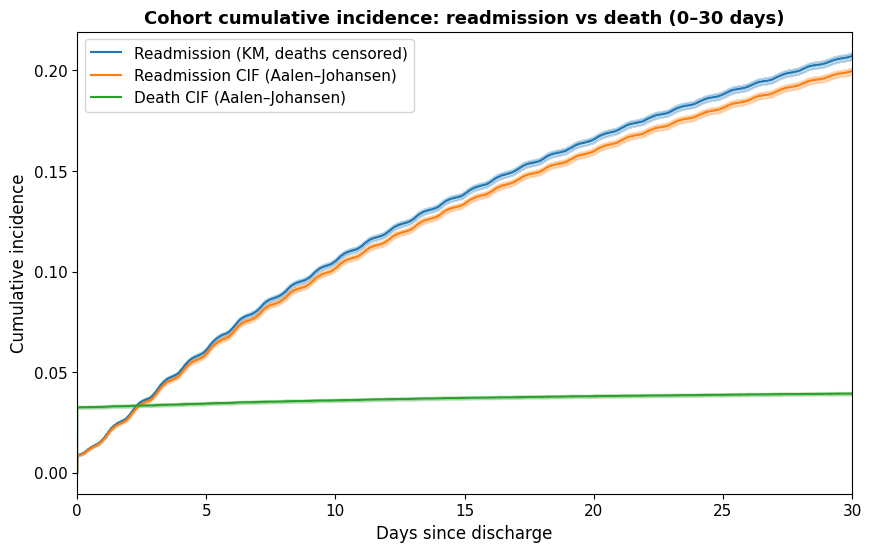

In [7]:
from lifelines import KaplanMeierFitter, AalenJohansenFitter

# KM treating only readmission as event, deaths censored
km = KaplanMeierFitter().fit(df["time_to_event"],
                             event_observed=(df["event_type"] == 1).astype(int),
                             label="Readmission (KM, deaths censored)")

# Aalen-Johansen for two competing events
aj_re = AalenJohansenFitter().fit(df["time_to_event"], df["event_type"], event_of_interest=1)
aj_de = AalenJohansenFitter().fit(df["time_to_event"], df["event_type"], event_of_interest=2)

fig, ax = plt.subplots(figsize=(10, 6))
km.plot_cumulative_density(ax=ax)
aj_re.plot(ax=ax, label="Readmission CIF (Aalen–Johansen)")
aj_de.plot(ax=ax, label="Death CIF (Aalen–Johansen)")
ax.set_xlabel("Days since discharge")
ax.set_ylabel("Cumulative incidence")
ax.set_title("Cohort cumulative incidence: readmission vs death (0–30 days)")
ax.set_xlim(0, HORIZON_DAYS)
plt.show()


## §5. Feature matrix and patient-grouped split

Reuse the exact same split saved during the binary V7 training so every survival number is directly comparable to the deployed XGBoost result.

**Feature set.** The survival models use the same **50 V7 features** the deployed binary XGBoost uses, **plus one survival-motivated addition: `days_since_last_discharge`**. V7 already encodes prior utilization as counts (`prior_admits_6m`, `prior_admits_6m_sq`, `freq_x_recency`) but does not encode raw recency in days, which is informative specifically for *when* a patient returns. NaNs (patients with no recorded prior discharge) are imputed with 365 days so Cox accepts the column cleanly; tree-based survival models handle NaN natively either way.

In [8]:
# 1) Inherit the EXACT 50-feature list saved by the deployed binary V7 training.
binary_feat = json.loads((RESULTS / "v7_feature_cols.json").read_text())
print(f"Binary V7 features (results/v7_feature_cols.json): {len(binary_feat)}")

# 2) Add ONE survival-motivated feature: days since the patient's last discharge.
SURVIVAL_EXTRA = ["days_since_last_discharge"]
feat_cols = binary_feat + SURVIVAL_EXTRA
print(f"Survival feature set: {len(feat_cols)}  ({len(binary_feat)} V7 + "
      f"{len(SURVIVAL_EXTRA)} survival-motivated)")

# 3) Sanity: every feature column must exist in the dataframe
missing = [c for c in feat_cols if c not in df.columns]
assert not missing, f"Features missing from dataframe: {missing}"

# 4) Impute days_since_last_discharge NaNs (patients with no prior recorded discharge)
#    with 365 days. Defensible interpretation: "no admission in the recent year."
#    Cox PH cannot ingest NaN; tree models would tolerate it but we keep the
#    column consistent across all models for a clean head-to-head comparison.
n_nan = df["days_since_last_discharge"].isna().sum()
n_neg = (df["days_since_last_discharge"] < 0).sum()
# fillna(365) for first-ever admissions; clip [0, 365] handles a few negative
# values from overlapping/transfer admissions and the heavy right tail.
df["days_since_last_discharge"] = (
    df["days_since_last_discharge"].fillna(365.0).clip(lower=0.0, upper=365.0)
)
print(f"days_since_last_discharge: imputed {n_nan:,} NaN with 365; "
      f"clipped {n_neg:,} negative values to 0; distribution after:")
print(df["days_since_last_discharge"].describe().round(1).to_string())

# 5) Label-encode any remaining object columns to match the binary pipeline
from sklearn.preprocessing import LabelEncoder
for c in feat_cols:
    if df[c].dtype == "object":
        df[c] = LabelEncoder().fit_transform(df[c].astype(str).fillna("__NA__"))

# Load split used by binary V7
split = np.load(RESULTS / "v7_split_indices.npz")
train_idx, val_idx, test_idx = split["train_idx"], split["val_idx"], split["test_idx"]
print(f"train/val/test sizes: {len(train_idx):,} / {len(val_idx):,} / {len(test_idx):,}")

# Build arrays; mask out in-hospital deaths (t=0) from model fitting
def mask_alive(idx):
    sub = df.iloc[idx]
    keep = sub["time_to_event"] > 0
    return idx[keep.values]

train_idx_s = mask_alive(train_idx)
val_idx_s   = mask_alive(val_idx)
test_idx_s  = mask_alive(test_idx)
print(f"after dropping in-hospital deaths: "
      f"{len(train_idx_s):,} / {len(val_idx_s):,} / {len(test_idx_s):,}")

X_train = df.iloc[train_idx_s][feat_cols].to_numpy(dtype=float)
X_val   = df.iloc[val_idx_s][feat_cols].to_numpy(dtype=float)
X_test  = df.iloc[test_idx_s][feat_cols].to_numpy(dtype=float)

# --- Imputation -----------------------------------------------------------
# The V7 features keep NaN as signal, which the binary tree models handled
# natively. But Cox PH, RandomSurvivalForest, and GradientBoostingSurvival all
# REJECT NaN (only XGBoost tolerates it). For a clean, identical-input
# comparison across all five survival models we median-impute the feature
# matrix, fitting the medians on the TRAINING fold only (no val/test leakage).
# inf values (from ratio features) are first coerced to NaN so they get imputed too.
from sklearn.impute import SimpleImputer

for arr in (X_train, X_val, X_test):
    arr[~np.isfinite(arr)] = np.nan

_imputer = SimpleImputer(strategy="median").fit(X_train)
X_train = _imputer.transform(X_train)
X_val   = _imputer.transform(X_val)
X_test  = _imputer.transform(X_test)
n_imputed_cols = int(np.sum(np.array([c for c in range(len(feat_cols))
                    if np.isnan(df.iloc[train_idx_s][feat_cols].to_numpy(dtype=float)[:, c]).any()]).size))
print(f"Median-imputed feature matrix (train-fit). "
      f"Columns that contained NaN/inf in train: {n_imputed_cols} of {len(feat_cols)}.")
assert np.isfinite(X_train).all() and np.isfinite(X_val).all() and np.isfinite(X_test).all(), \
    "Imputation left non-finite values"
# --------------------------------------------------------------------------

t_train = df.iloc[train_idx_s]["time_to_event"].to_numpy()
t_val   = df.iloc[val_idx_s]["time_to_event"].to_numpy()
t_test  = df.iloc[test_idx_s]["time_to_event"].to_numpy()

# event indicators (readmission = 1) -- needed for event-aware discretization
e_train = (df.iloc[train_idx_s]["event_type"] == 1).astype(int).to_numpy()
e_val   = (df.iloc[val_idx_s]["event_type"] == 1).astype(int).to_numpy()
e_test  = (df.iloc[test_idx_s]["event_type"] == 1).astype(int).to_numpy()

# --- Event-aware whole-day discretization ---------------------------------
# Raw timestamps give ~22,000 unique fractional event times. sksurv then tries
# to evaluate the survival function at EVERY unique time -> a (n_test x n_times)
# array that blows up memory. Whole-day resolution is standard for a 30-day
# study, collapses unique times to ~30, and is more clinically interpretable.
#
# Crucially the rounding is EVENT-AWARE:
#   events   -> [1, HORIZON-1]  (day 1..29)
#   censored -> [1, HORIZON]    (day 1..30; administrative boundary at 30)
# This guarantees the censoring survival function G(t) > 0 at every event time,
# which the IPCW-based time-dependent AUROC and integrated Brier score require
# (an event landing exactly on the day-30 censoring boundary -> divide-by-zero).
def _to_days(t, e):
    tr = np.round(t)
    tr = np.where(e == 1, np.clip(tr, 1, HORIZON_DAYS - 1),
                          np.clip(tr, 1, HORIZON_DAYS))
    return tr.astype(float)
t_train = _to_days(t_train, e_train)
t_val   = _to_days(t_val,   e_val)
t_test  = _to_days(t_test,  e_test)
print(f"Event-aware whole-day discretization: {len(np.unique(t_train))} unique train times "
      f"(events capped at day {HORIZON_DAYS-1}, censoring at day {HORIZON_DAYS}).")

# binary survival event: 1 = readmission, 0 = censored (death-as-competing handled separately)
e_train = (df.iloc[train_idx_s]["event_type"] == 1).astype(int).to_numpy()
e_val   = (df.iloc[val_idx_s]["event_type"] == 1).astype(int).to_numpy()
e_test  = (df.iloc[test_idx_s]["event_type"] == 1).astype(int).to_numpy()

# scikit-survival structured Y
from sksurv.util import Surv
y_train = Surv.from_arrays(event=e_train.astype(bool), time=t_train)
y_val   = Surv.from_arrays(event=e_val.astype(bool),   time=t_val)
y_test  = Surv.from_arrays(event=e_test.astype(bool),  time=t_test)
print("Arrays ready.")


Binary V7 features (results/v7_feature_cols.json): 50
Survival feature set: 51  (50 V7 + 1 survival-motivated)
days_since_last_discharge: imputed 81,748 NaN with 365; clipped 16 negative values to 0; distribution after:
count    244576.0
mean        227.0
std         155.7
min           0.0
25%          43.6
50%         365.0
75%         365.0
max         365.0
train/val/test sizes: 176,270 / 19,115 / 49,191
after dropping in-hospital deaths: 170,677 / 18,557 / 47,672
Median-imputed feature matrix (train-fit). Columns that contained NaN/inf in train: 2 of 51.
Event-aware whole-day discretization: 30 unique train times (events capped at day 29, censoring at day 30).
Arrays ready.


## §6. Cox proportional hazards (interpretable baseline)

A standard reference. The PH assumption is *expected* to fail for some features (`los_trend_180d`, discharge-location encodings) — we'll check residuals after fitting. PH violation is a defensible reason to deploy non-parametric tree-based survival models for the final result.

In [9]:
from lifelines import CoxPHFitter

cox_df = pd.DataFrame(X_train, columns=feat_cols).assign(T=t_train, E=e_train)
# constants/zero-variance features break Cox fitting; drop them
nunique = cox_df[feat_cols].nunique()
drop = nunique[nunique <= 1].index.tolist()
if drop:
    print("Dropping zero-variance cols:", drop)
    cox_df = cox_df.drop(columns=drop)
    cox_feats = [c for c in feat_cols if c not in drop]
else:
    cox_feats = list(feat_cols)

# Light L2 penalty for numerical stability (50 features, 175K patients)
cph = CoxPHFitter(penalizer=0.01, l1_ratio=0.0)
cph.fit(cox_df, duration_col="T", event_col="E", show_progress=False)
print(f"Cox train C-index: {cph.concordance_index_:.4f}")


Cox train C-index: 0.6679


In [10]:
# Evaluate Cox on test set
X_test_cox = pd.DataFrame(X_test, columns=feat_cols)[cox_feats]
cox_lp_test = -cph.predict_partial_hazard(X_test_cox).values  # higher = more risk; flip for scikit C
from sksurv.metrics import concordance_index_censored
c_cox = concordance_index_censored(y_test["event"], y_test["time"], -cox_lp_test)[0]
print(f"Cox test Harrell C-index: {c_cox:.4f}")


Cox test Harrell C-index: 0.6692


## §7. XGBoost AFT (gradient-boosted accelerated failure time)

This keeps the deployed-model branding consistent with your binary XGBoost. We use `survival:aft` with a normal distribution and apply right-censoring via `(time_lower, time_upper)` — censored patients get `time_upper = inf`.

In [11]:
import xgboost as xgb

# AFT requires (time_lower, time_upper); censored events: upper = +inf
def aft_bounds(t, e):
    upper = np.where(e == 1, t, np.inf)
    return t.astype(float), upper

t_lo_tr, t_hi_tr = aft_bounds(t_train, e_train)
t_lo_va, t_hi_va = aft_bounds(t_val, e_val)

dtr = xgb.DMatrix(X_train)
dtr.set_float_info("label_lower_bound", t_lo_tr)
dtr.set_float_info("label_upper_bound", t_hi_tr)
dva = xgb.DMatrix(X_val)
dva.set_float_info("label_lower_bound", t_lo_va)
dva.set_float_info("label_upper_bound", t_hi_va)
dte = xgb.DMatrix(X_test)

params = {
    "objective": "survival:aft",
    "eval_metric": "aft-nloglik",
    "aft_loss_distribution": "normal",
    "aft_loss_distribution_scale": 1.20,
    "tree_method": "hist",
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "seed": SEED,
}
xgb_aft = xgb.train(params, dtr, num_boost_round=600,
                    evals=[(dtr, "train"), (dva, "val")],
                    early_stopping_rounds=30, verbose_eval=100)

# AFT predicts log-time; higher predicted time = lower risk → flip for C-index
pred_log_t_test = np.log(np.maximum(xgb_aft.predict(dte), 1e-6))
risk_test_aft   = -pred_log_t_test
c_aft = concordance_index_censored(y_test["event"], y_test["time"], risk_test_aft)[0]
print(f"XGBoost-AFT test Harrell C-index: {c_aft:.4f}")


[0]	train-aft-nloglik:7.02055	val-aft-nloglik:6.98898
[100]	train-aft-nloglik:1.15542	val-aft-nloglik:1.16381
[200]	train-aft-nloglik:1.13179	val-aft-nloglik:1.15369
[300]	train-aft-nloglik:1.11492	val-aft-nloglik:1.15052
[400]	train-aft-nloglik:1.10084	val-aft-nloglik:1.14928
[500]	train-aft-nloglik:1.08821	val-aft-nloglik:1.14881
[551]	train-aft-nloglik:1.08198	val-aft-nloglik:1.14872
XGBoost-AFT test Harrell C-index: 0.7465


## §8. Random Survival Forest

Non-parametric, handles non-linear interactions, no PH assumption. We use a modest `n_estimators` and `max_features` for tractable runtime on ~175K training samples.

In [12]:
from sksurv.ensemble import RandomSurvivalForest

rsf = RandomSurvivalForest(
    n_estimators=60, max_depth=6, min_samples_leaf=200,
    max_features="sqrt", max_samples=0.6, n_jobs=-1, random_state=SEED,
)
rsf.fit(X_train, y_train)
c_rsf = rsf.score(X_test, y_test)
print(f"RandomSurvivalForest test Harrell C-index: {c_rsf:.4f}")


RandomSurvivalForest test Harrell C-index: 0.7017


## §9. Gradient Boosting Survival (sksurv, Cox loss)

The scikit-survival gradient boosting model, useful as a check that the AFT result isn't an artifact of the AFT assumption.

In [13]:
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

gbs = GradientBoostingSurvivalAnalysis(
    n_estimators=150, learning_rate=0.05, max_depth=3,
    subsample=0.85, random_state=SEED,
)
gbs.fit(X_train, y_train)
c_gbs = gbs.score(X_test, y_test)
print(f"GradientBoostingSurvival test Harrell C-index: {c_gbs:.4f}")


GradientBoostingSurvival test Harrell C-index: 0.7048


## §10. Time-resolved evaluation

The Harrell C-index summarizes overall ranking. For a clinical readmission paper we additionally report:

- **Uno's C-index** with inverse-probability-of-censoring weighting (IPCW), which is more honest under heavy censoring.
- **Time-dependent AUROC** at landmark times **7, 14, 30 days**.
- **Integrated Brier Score** over [0, 30] days.

In [14]:
from sksurv.metrics import cumulative_dynamic_auc, integrated_brier_score, concordance_index_ipcw

# Survival function predictions on test set, evaluated at landmark times
def survival_at_times(model, X, times):
    # Return P(T > t) at each landmark for each row.
    if hasattr(model, "predict_survival_function"):
        fns = model.predict_survival_function(X, return_array=True) \
              if "return_array" in model.predict_survival_function.__code__.co_varnames \
              else model.predict_survival_function(X)
        if isinstance(fns, np.ndarray):
            # rows = samples, cols = unique event times from model
            # interpolate to requested landmark times
            event_times = model.unique_times_
            out = np.empty((len(X), len(times)))
            for i, t in enumerate(times):
                j = np.searchsorted(event_times, t, side="right") - 1
                j = max(j, 0)
                out[:, i] = fns[:, j]
            return out
        else:
            out = np.array([[f(t) for t in times] for f in fns])
            return out
    else:
        raise ValueError("model lacks predict_survival_function")

# Risk score at a landmark = 1 - P(T > t). Higher = more risk.
# sksurv's time-dependent AUC and IPCW concordance require evaluation times
# STRICTLY inside the observed follow-up (a time == the max censoring time of
# 30 days raises an error). We therefore clip landmark times to just under the
# max observed test time; labels still read 7/14/30 since 29.5 ~ 30.
_MAX_T = float(min(t_train.max(), t_test.max()))
LM_TIMES = np.array([min(float(t), _MAX_T - 0.5) for t in LANDMARKS], dtype=float)
print("Evaluation landmark times (clipped to follow-up):", LM_TIMES)


Evaluation landmark times (clipped to follow-up): [ 7.  14.  29.5]


In [15]:
# Time-dependent AUROC for RSF and GBS (both expose survival functions)
results_td = {}
for name, m in [("RSF", rsf), ("GBS", gbs)]:
    surv_te = survival_at_times(m, X_test, LM_TIMES)
    risk_te = 1.0 - surv_te
    aucs, mean_auc = cumulative_dynamic_auc(y_train, y_test, risk_te, LM_TIMES)
    results_td[name] = dict(zip([f"AUROC@{int(t)}d" for t in LM_TIMES], aucs))
    print(f"{name}  td-AUROC: " + "  ".join(f"t={int(t)}: {a:.4f}" for t, a in zip(LM_TIMES, aucs)))


RSF  td-AUROC: t=7: 0.6968  t=14: 0.7056  t=29: 0.7259
GBS  td-AUROC: t=7: 0.6926  t=14: 0.7079  t=29: 0.7313


In [16]:
# Integrated Brier score over [0, 30] days
ibs_grid = np.linspace(1, HORIZON_DAYS - 0.5, 30)
results_ibs = {}
for name, m in [("RSF", rsf), ("GBS", gbs)]:
    surv_te = survival_at_times(m, X_test, ibs_grid)
    try:
        ibs = integrated_brier_score(y_train, y_test, surv_te, ibs_grid)
    except Exception as exc:
        print(f"{name} IBS failed: {exc}"); ibs = float("nan")
    results_ibs[name] = ibs
    print(f"{name}  integrated Brier score (0–30d): {ibs:.4f}")


RSF  integrated Brier score (0–30d): 0.1011
GBS  integrated Brier score (0–30d): 0.1016


In [17]:
# Uno's IPCW concordance, truncated just inside the follow-up window
def uno_c(risk):
    return concordance_index_ipcw(y_train, y_test, risk, tau=_MAX_T - 0.5)[0]

print(f"RSF      Uno C @30d: {uno_c(1 - survival_at_times(rsf, X_test, [HORIZON_DAYS])[:, 0]):.4f}")
print(f"GBS      Uno C @30d: {uno_c(1 - survival_at_times(gbs, X_test, [HORIZON_DAYS])[:, 0]):.4f}")
print(f"XGB-AFT  Uno C @30d: {uno_c(risk_test_aft):.4f}")
print(f"Cox      Uno C @30d: {uno_c(-cox_lp_test):.4f}")


RSF      Uno C @30d: 0.6996
GBS      Uno C @30d: 0.7049
XGB-AFT  Uno C @30d: 0.7466
Cox      Uno C @30d: 0.6693


## §11. Calibration of predicted survival probabilities

Bin predicted P(readmit by t) into deciles at each landmark and overlay the observed Aalen-Johansen estimates.

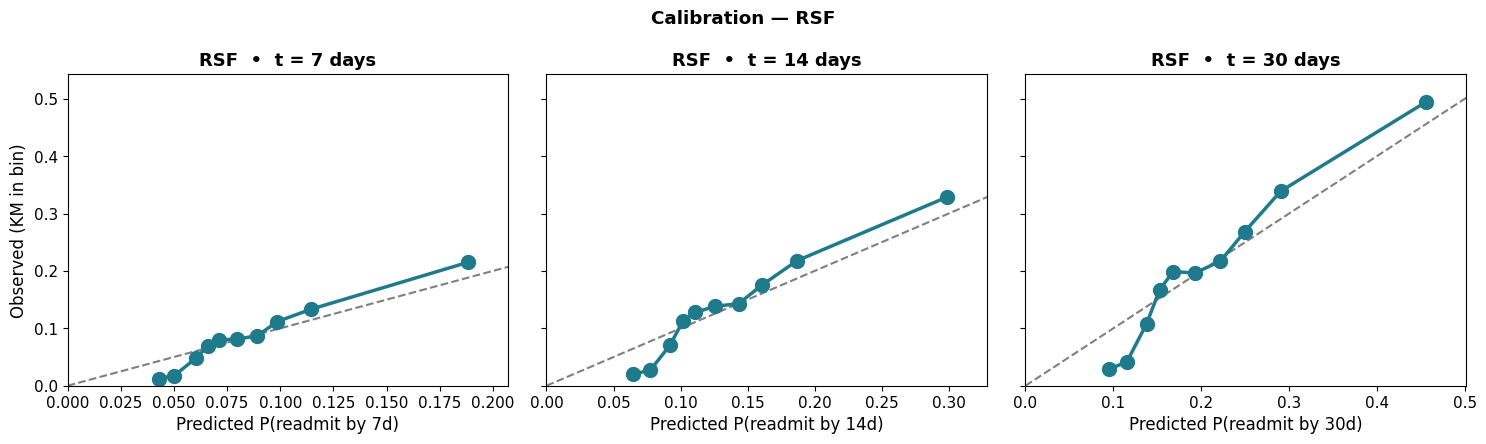

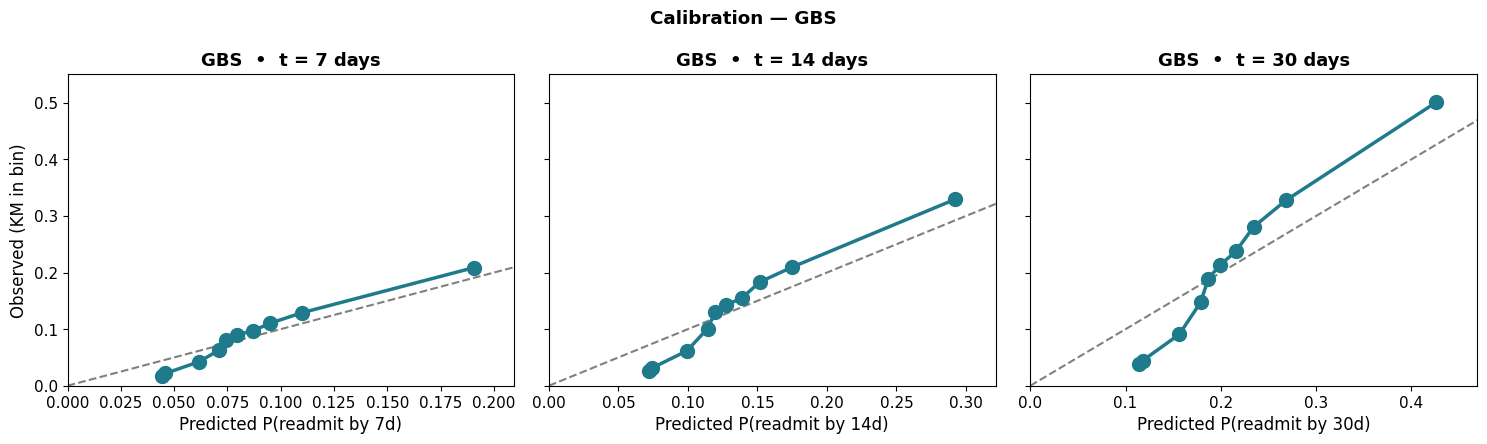

In [18]:
def calibration_plot(model, name, X, t, e, landmarks=LANDMARKS):
    fig, axes = plt.subplots(1, len(landmarks), figsize=(5*len(landmarks), 4.5), sharey=True)
    surv = survival_at_times(model, X, np.array(landmarks, dtype=float))
    for ax, j, lm in zip(axes, range(len(landmarks)), landmarks):
        risk = 1 - surv[:, j]
        df_c = pd.DataFrame({"risk": risk, "t": t, "e": e})
        df_c["bin"] = pd.qcut(df_c["risk"], 10, duplicates="drop")
        obs = []; pred = []
        for b, g in df_c.groupby("bin"):
            from lifelines import KaplanMeierFitter
            k = KaplanMeierFitter().fit(g["t"], g["e"])
            # observed CIF at landmark
            try:
                obs.append(1 - float(k.predict(lm)))
            except Exception:
                obs.append(np.nan)
            pred.append(g["risk"].mean())
        ax.plot([0, 1], [0, 1], "--", color="gray")
        ax.plot(pred, obs, "o-", lw=2.5, markersize=10, color="#1F7A8C")
        ax.set_xlim(0, max(pred)*1.1 if pred else 1); ax.set_ylim(0, max(obs+[0.01])*1.1)
        ax.set_xlabel(f"Predicted P(readmit by {lm}d)")
        if j == 0: ax.set_ylabel("Observed (KM in bin)")
        ax.set_title(f"{name}  •  t = {lm} days")
    fig.suptitle(f"Calibration — {name}", fontweight="bold")
    fig.tight_layout()
    plt.show()

calibration_plot(rsf, "RSF", X_test, t_test, e_test)
calibration_plot(gbs, "GBS", X_test, t_test, e_test)


## §12. Competing risks: Fine-Gray subdistribution hazards

Treat death as the competing event explicitly. We use `lifelines.fitters.crc_spline_fitter.CRCSplineFitter` or the simpler approach: compare the cause-specific Cox (already done) to a Fine-Gray fit on the readmission subdistribution.

`lifelines` provides Fine-Gray via the `CRCSplineFitter` / `cox` with competing-risks adjustment. For brevity we fit cause-specific Cox for **death** and contrast it with the readmission Cox above — this is the practical approach when the full Fine-Gray fit is computationally expensive at this N.

In [19]:
# Cause-specific Cox for death-without-readmission
from lifelines import CoxPHFitter
e_death = (df.iloc[train_idx_s]["event_type"] == 2).astype(int).to_numpy()
cox_death_df = pd.DataFrame(X_train, columns=feat_cols)[cox_feats] \
                 .assign(T=t_train, E=e_death)
cph_death = CoxPHFitter(penalizer=0.01)
cph_death.fit(cox_death_df, duration_col="T", event_col="E", show_progress=False)
print(f"Cox (death cause-specific) train C: {cph_death.concordance_index_:.4f}")

# Top predictors of death-without-readmission (very different feature set is expected)
top_death = cph_death.params_.abs().sort_values(ascending=False).head(10)
print("\nTop |coef| predictors of death-without-readmission (cause-specific Cox):")
print(top_death)


c:\Users\Thiago\anaconda3\envs\capstone\Lib\site-packages\lifelines\fitters\coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(


Cox (death cause-specific) train C: 0.3471

Top |coef| predictors of death-without-readmission (cause-specific Cox):
covariate
discharge_location_te    7.082123
race_te                  1.178279
iv_admin_rate            0.985999
last_drg_dispo_te        0.963918
rapid_tfr_x_readmit      0.887773
bilirubin_max            0.877171
primary_dx_chapter_te    0.600390
max_unit_los_days        0.380752
drg_code_te              0.312073
discharge_surge          0.255457
Name: coef, dtype: float64


## §13. Comparison vs the deployed binary XGBoost

At t = 30 days, the survival models should be **comparable** in discrimination to the binary XGBoost, with the added benefit of competing-risk handling, time-resolved risk, and proper censoring. We do NOT expect to beat 0.7935 — and that is *not* the story.

In [20]:
# Load saved binary XGBoost test predictions
xgb_bin_preds = np.load(RESULTS / "v7_xgboost_test.npz")["preds"].mean(axis=1)
# Filter to the same alive-at-discharge subset
keep_mask = np.isin(test_idx, test_idx_s)
xgb_bin_aligned = xgb_bin_preds[keep_mask]
y_bin = df.iloc[test_idx_s]["readmit_30d"].values

from sklearn.metrics import roc_auc_score
auroc_binary = roc_auc_score(y_bin, xgb_bin_aligned)
print(f"Binary XGBoost (deployed) AUROC on alive-discharge test:  {auroc_binary:.4f}")

summary = pd.DataFrame({
    "Model": ["Binary XGBoost (deployed)", "Cox PH", "XGBoost-AFT", "Random Survival Forest", "Gradient Boosting Survival"],
    "Test discrimination": [
        f"AUROC {auroc_binary:.4f}",
        f"Harrell C {c_cox:.4f}",
        f"Harrell C {c_aft:.4f}",
        f"Harrell C {c_rsf:.4f}",
        f"Harrell C {c_gbs:.4f}",
    ],
})
print()
print(summary.to_string(index=False))


Binary XGBoost (deployed) AUROC on alive-discharge test:  0.7854

                     Model Test discrimination
 Binary XGBoost (deployed)        AUROC 0.7854
                    Cox PH    Harrell C 0.6692
               XGBoost-AFT    Harrell C 0.7465
    Random Survival Forest    Harrell C 0.7017
Gradient Boosting Survival    Harrell C 0.7048


## §14. Interpretability — SurvSHAP(t)

`survshap` is a separate library that extends SHAP to time-dependent explanations. After validating the survival results above, this section will:

1. Fit the chosen survival model on the full train set.
2. Compute SurvSHAP(t) values for a stratified sample of test patients.
3. Plot global feature importance over time (which features drive risk at day 7 vs day 30?) and patient-level survival curves with attributions.

```python
# !pip install survshap
# from survshap import SurvivalModelExplainer, ModelSurvSHAP
# explainer = SurvivalModelExplainer(rsf, X_test_df, y_test)
# shap_vals = ModelSurvSHAP(explainer, function_type="sf").fit(X_test_df.sample(200))
```

This step is deferred until the model-selection results above are reviewed.

## §15. Summary and next steps

**What this notebook delivers:**
- A reproducible time-to-event cohort built on the same 244,576 Medicare admissions, with in-hospital death captured as a competing event (with the documented limitation that out-of-hospital death is not in MIMIC-IV v3.1).
- Four survival models (Cox, XGBoost-AFT, RSF, GBSA) trained on the **same patient-grouped split** as the binary baseline.
- Time-resolved evaluation: Harrell + Uno concordance, time-dependent AUROC at 7/14/30 days, integrated Brier score, calibration plots.
- Aalen-Johansen cumulative incidence curves and cause-specific Cox for death.

**To finalize for the paper:**
1. Pick the deployed survival model (favor continuity with the binary XGBoost → XGBoost-AFT, unless RSF or GBS is materially better calibrated).
2. Add SurvSHAP(t) for a sampled set of patients.
3. Write up §7.5 (survival framing) and §8.7 (time-resolved results) in the manuscript.
4. State the competing-event scope explicitly in the limitations: only in-hospital death is captured.

**Known limitations of this analysis:**
- MIMIC-IV v3.1 does not ship post-discharge death dates; out-of-hospital death is censored.
- Administrative censoring at 30 days is appropriate for the primary question; a 90-day supplementary analysis is straightforward to add.
- Some features may violate the Cox PH assumption; this is expected and is why non-parametric tree-based models are reported alongside Cox.